# Chapter 34: Pseudo-Labeling

**How much does the shortcut teacher inflate the student's cross-validation score, and what does honest pseudo-labeling add?**

Pseudo-labeling is often reported as a large gain, and the shortcut that produces a large gain is easy to write. Scoring both pipelines against fresh rows shows how much of the gain is information from the validation labels.

*Constructed data; honest pseudo-labeling added about 0.01 AUC at most here, and the sizes of every effect are properties of this generator, not a competition result.*

## The experiment

Eight constructed binary tasks with 600 labeled rows, eight features and a nonlinear log-odds function, plus a pool of unlabeled recipients whose size is the control. Three fold models are trained as in ordinary 3-fold training: model k excludes fold k. For fold k the eligible teacher is model k; the shortcut teacher averages the other two models, which were trained on fold k. Recipients whose teacher probability is above 0.8 or below 0.2 are added to the training rows with the teacher's hard label, a histogram gradient boosting student is fitted, and it is scored on the untouched labeled fold (pooled AUC) and on 5,000 fresh rows. The supervised model with no pseudo-labels is the baseline.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from kaggle_companion.activities._common import clean

SEED = 34
REPLICATES = 8          # independent constructed datasets; every estimate is their mean
FEATURES, N_LABELED, N_FRESH, FOLDS = 8, 600, 5000, 3
CONFIDENCE = 0.3        # keep a pseudo-label only when the teacher's probability is more than 0.3 from 0.5


def make_signal(rng):
    """A fixed nonlinear log-odds function: a linear part, a sine of a random projection and one interaction."""
    w, v = rng.normal(size=FEATURES), rng.normal(size=FEATURES)
    return lambda X: 1.2 * (X @ w) / np.sqrt(FEATURES) + 0.9 * np.sin(X @ v) + 0.6 * X[:, 0] * X[:, 1]


def sample(signal, n, rng):
    X = rng.normal(size=(n, FEATURES))
    return X, (rng.random(n) < 1 / (1 + np.exp(-signal(X)))).astype(int)


def model():
    return HistGradientBoostingClassifier(max_iter=60, max_leaf_nodes=8, max_bins=32, random_state=0)


def student(X_train, y_train, X_recipients, teacher_probability):
    """Fit on the training rows plus the recipients whose pseudo-label the teacher is confident about."""
    keep = np.abs(teacher_probability - 0.5) > CONFIDENCE
    X = np.vstack([X_train, X_recipients[keep]])
    y = np.concatenate([y_train, (teacher_probability[keep] > 0.5).astype(int)])
    return model().fit(X, y), keep


def one_replicate(recipients, seed):
    rng = np.random.default_rng(seed)
    signal = make_signal(rng)
    X, y = sample(signal, N_LABELED, rng)                     # genuinely labeled rows: the only rows ever scored by CV
    X_new, y_new = sample(signal, N_FRESH, rng)               # fresh rows from the same generator: the "truth"
    X_rec, y_rec = sample(signal, recipients, rng)            # recipients; y_rec is used only to audit pseudo-label accuracy
    folds = list(StratifiedKFold(FOLDS, shuffle=True, random_state=1).split(X, y))
    fold_models = [model().fit(X[a], y[a]) for a, _ in folds]   # ordinary K-fold models: model k never saw fold k

    pooled = {name: np.zeros(N_LABELED) for name in ("supervised", "eligible", "shortcut")}
    fresh = {name: [] for name in pooled}
    audit = {"eligible": [], "shortcut": []}
    for k, (train, valid) in enumerate(folds):
        teachers = {
            "eligible": fold_models[k].predict_proba(X_rec)[:, 1],       # model k: trained on outer-training rows only
            # The shortcut: average every model except k. Each of them was trained on fold k's labels.
            "shortcut": np.mean([fold_models[j].predict_proba(X_rec)[:, 1] for j in range(FOLDS) if j != k], axis=0)}
        fitted = {"supervised": fold_models[k]}
        for name, probability in teachers.items():
            fitted[name], keep = student(X[train], y[train], X_rec, probability)
            audit[name].append((keep.sum(), float(np.mean((probability[keep] > 0.5) == y_rec[keep])) if keep.any() else 0.0))
        for name, fit in fitted.items():
            pooled[name][valid] = fit.predict_proba(X[valid])[:, 1]       # score the untouched genuine fold
            fresh[name].append(roc_auc_score(y_new, fit.predict_proba(X_new)[:, 1]))
    out = {name: (roc_auc_score(y, pooled[name]), float(np.mean(fresh[name]))) for name in pooled}
    out["kept"] = {n: float(np.mean([a[0] for a in audit[n]])) for n in audit}
    out["all_labels_fresh"] = roc_auc_score(y_new, model().fit(X, y).predict_proba(X_new)[:, 1])   # reference: all 600 labels, no pseudo-labels
    out["accuracy"] = {n: float(np.mean([a[1] for a in audit[n]])) for n in audit}
    return out


def run(recipients):
    reps = [one_replicate(recipients, SEED * 100 + i) for i in range(REPLICATES)]
    result = {"recipients": recipients, "replicates": REPLICATES, "labeled_rows": N_LABELED, "fresh_rows": N_FRESH}
    for name in ("supervised", "eligible", "shortcut"):
        result[name] = {"cv": float(np.mean([r[name][0] for r in reps])), "fresh": float(np.mean([r[name][1] for r in reps]))}
    result["kept"] = {n: float(np.mean([r["kept"][n] for r in reps])) for n in ("eligible", "shortcut")}
    result["all_labels_fresh"] = float(np.mean([r["all_labels_fresh"] for r in reps]))
    result["eligible_gain_positive"] = int(sum(r["eligible"][1] > r["supervised"][1] for r in reps))   # datasets where it helped
    result["accuracy"] = {n: float(np.mean([r["accuracy"][n] for r in reps])) for n in ("eligible", "shortcut")}
    return clean(result)


## Measure it across the control

The control is **unlabeled recipients available for pseudo-labeling**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch34 import explain

VALUES = [250, 750, 1500, 4500]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                        250    750   1500   4500
Shortcut CV           0.729  0.759  0.775  0.797
Shortcut, fresh rows  0.711  0.719  0.721  0.723
Eligible CV           0.703  0.709  0.707  0.709
Eligible, fresh rows  0.706  0.710  0.709  0.711
Baseline CV           0.704  0.704  0.704  0.704
Baseline, fresh rows  0.705  0.705  0.705  0.705


## Look at it

The figure shows the default setting, unlabeled recipients available for pseudo-labeling = 1500.

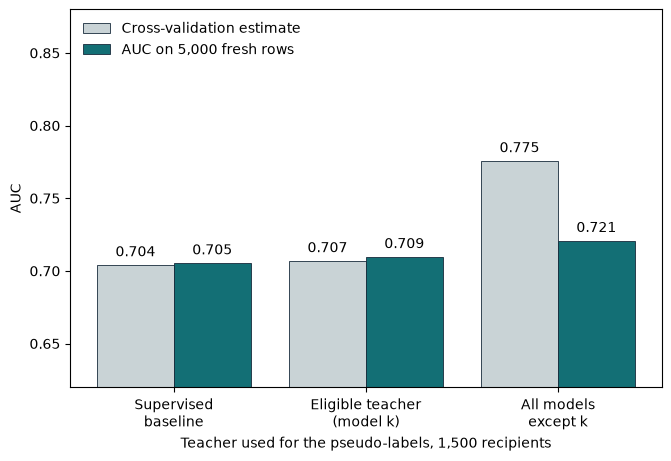

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch34 import draw, NCOLS, HEIGHT

DEFAULT = 1500
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 1,500 recipients the shortcut teacher reports 0.775 but its student scores 0.721 on fresh rows, 0.775 - 0.721 = 0.054 of optimism, a claimed gain of 0.071 over the baseline's 0.704. The eligible teacher reports 0.707 and scores 0.709 on fresh rows, -0.002 apart, a real change of +0.004 against the baseline's 0.705. The teachers kept 514 (eligible) and 432 (shortcut) pseudo-labels per fold, with accuracy 0.758 and 0.794.

- Shortcut: 0.775 - 0.721 = 0.054 (estimate minus fresh rows).
- Eligible: 0.707 - 0.709 = -0.002.
- Claimed gain of the shortcut: 0.775 - 0.704 = 0.071.
- Real gain of the eligible teacher on fresh rows: 0.709 - 0.705 = +0.004.

## Apply this to your competition

- Write down, for each pseudo-label, which labels its teacher trained on; a teacher is eligible only if its training labels exclude the fold being scored.
- Score each outer fold's untouched genuine labels, never the pseudo-labeled recipients and never rows that duplicate a validation row.
- Compare against the supervised baseline on the same folds, and treat a large gain as a reason to re-check the teacher.
- Tune confidence, weights and recipient counts inside the outer training data, not on the assessment fold.

Book location: Chapter 34, Trace the Teacher's Training Labels.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)